In [15]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using DataFrames

In [16]:
using Revise
using Newtrinos
using Newtrinos.osc

In [17]:
osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

Newtrinos.osc.Osc(OscillationConfig{NNM, SI, Basic, Newtrinos.osc.All}(NNM(ThreeFlavour(:NO)), SI(), Basic(), Newtrinos.osc.All()), (m₀ = 0.1, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761, δCP = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, N = 10.0, r = 1.0), (m₀ = Uniform{Float64}(a=1.0e-7, b=2.0), θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), N = Uniform{Float64}(a=3.0, b=100.0), r = Uniform{Float64}(a=0.0, b=1.0)), Newtrinos.osc.var"#get_Nnaturalness#52"(), Newtrinos.osc.var"#osc_prob#43"{Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NNM, SI, Basic, Newtrinos.osc.All}}}(Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NNM, SI, Basic, Newtrinos.osc.All}}(OscillationCon

In [20]:

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()
xsec = Newtrinos.xsec.configure()

physics = (; osc, atm_flux, earth_layers, xsec);

In [21]:
experiments = (
 
    minos = Newtrinos.minos.configure(physics),
);

[ Info: Loading minos data


In [22]:
p = Newtrinos.get_params(experiments)

(N = 10.0, m₀ = 0.1, nc_norm = 1.0, nutau_cc_norm = 1.0, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [23]:
asimov_data= Newtrinos.generate_asimov_data(experiments.minos, p)

[ Info: Not Poisson-based model. Returning std floating-point Asimov data.


(CC = [8.327568912281027, 7.793408085993196, 9.647402171500982, 14.982749759281354, 26.47652232315548, 43.094236401497874, 63.66869745225113, 84.86793350944677, 106.3609772890251, 124.88621086528227  …  87.67168322035577, 78.41667541108383, 70.14599927968261, 120.32110651633258, 97.84518309796505, 81.35607267820062, 66.70735258926469, 56.02528635153047, 87.55856050201776, 90.60985419101584], NC = [38.395706035844256, 221.63167607975166, 194.0534518937828, 178.986032141338, 174.9567724160307, 177.35703146725902, 180.3446593181166, 176.1391836331668, 162.2691057930766, 146.12251326268026  …  102.55857107235566, 67.98368393041177, 50.876427106294116, 38.6709377759933, 30.146276838105067, 42.49901514218212, 27.58258571107535, 18.25364867929251, 12.376167760655882, 8.794188060241092])

In [24]:
observed_data= experiments.minos.assets.observed

(CC = [13.0, 9.0, 9.0, 19.0, 30.0, 44.0, 47.0, 86.0, 109.0, 151.0  …  102.0, 80.0, 80.0, 127.0, 100.0, 87.0, 78.0, 55.0, 115.0, 101.0], NC = [47.0, 256.0, 205.0, 189.0, 183.0, 194.0, 182.0, 187.0, 173.0, 136.0  …  102.0, 76.0, 52.0, 37.0, 28.0, 40.0, 35.0, 22.0, 11.0, 12.0])

In [29]:
poisson_err_as=(poisson_err_ascc=sqrt.(asimov_data.CC), poisson_err_asnc=sqrt.(asimov_data.NC))
poisson_err_ob=(poisson_err_obcc=sqrt.(observed_data.CC), poisson_err_obnc=sqrt.(observed_data.NC))

(poisson_err_obcc = [3.605551275463989, 3.0, 3.0, 4.358898943540674, 5.477225575051661, 6.6332495807108, 6.855654600401044, 9.273618495495704, 10.44030650891055, 12.288205727444508  …  10.099504938362077, 8.94427190999916, 8.94427190999916, 11.269427669584644, 10.0, 9.327379053088816, 8.831760866327848, 7.416198487095663, 10.723805294763608, 10.04987562112089], poisson_err_obnc = [6.855654600401044, 16.0, 14.317821063276353, 13.74772708486752, 13.527749258468683, 13.92838827718412, 13.490737563232042, 13.674794331177344, 13.152946437965905, 11.661903789690601  …  10.099504938362077, 8.717797887081348, 7.211102550927978, 6.082762530298219, 5.291502622129181, 6.324555320336759, 5.916079783099616, 4.69041575982343, 3.3166247903554, 3.4641016151377544])

In [30]:
using CairoMakie

In [34]:
energy= experiments.minos.assets.ch_data["FD"*String(NC)].bin_edges

LoadError: UndefVarError: `NC` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

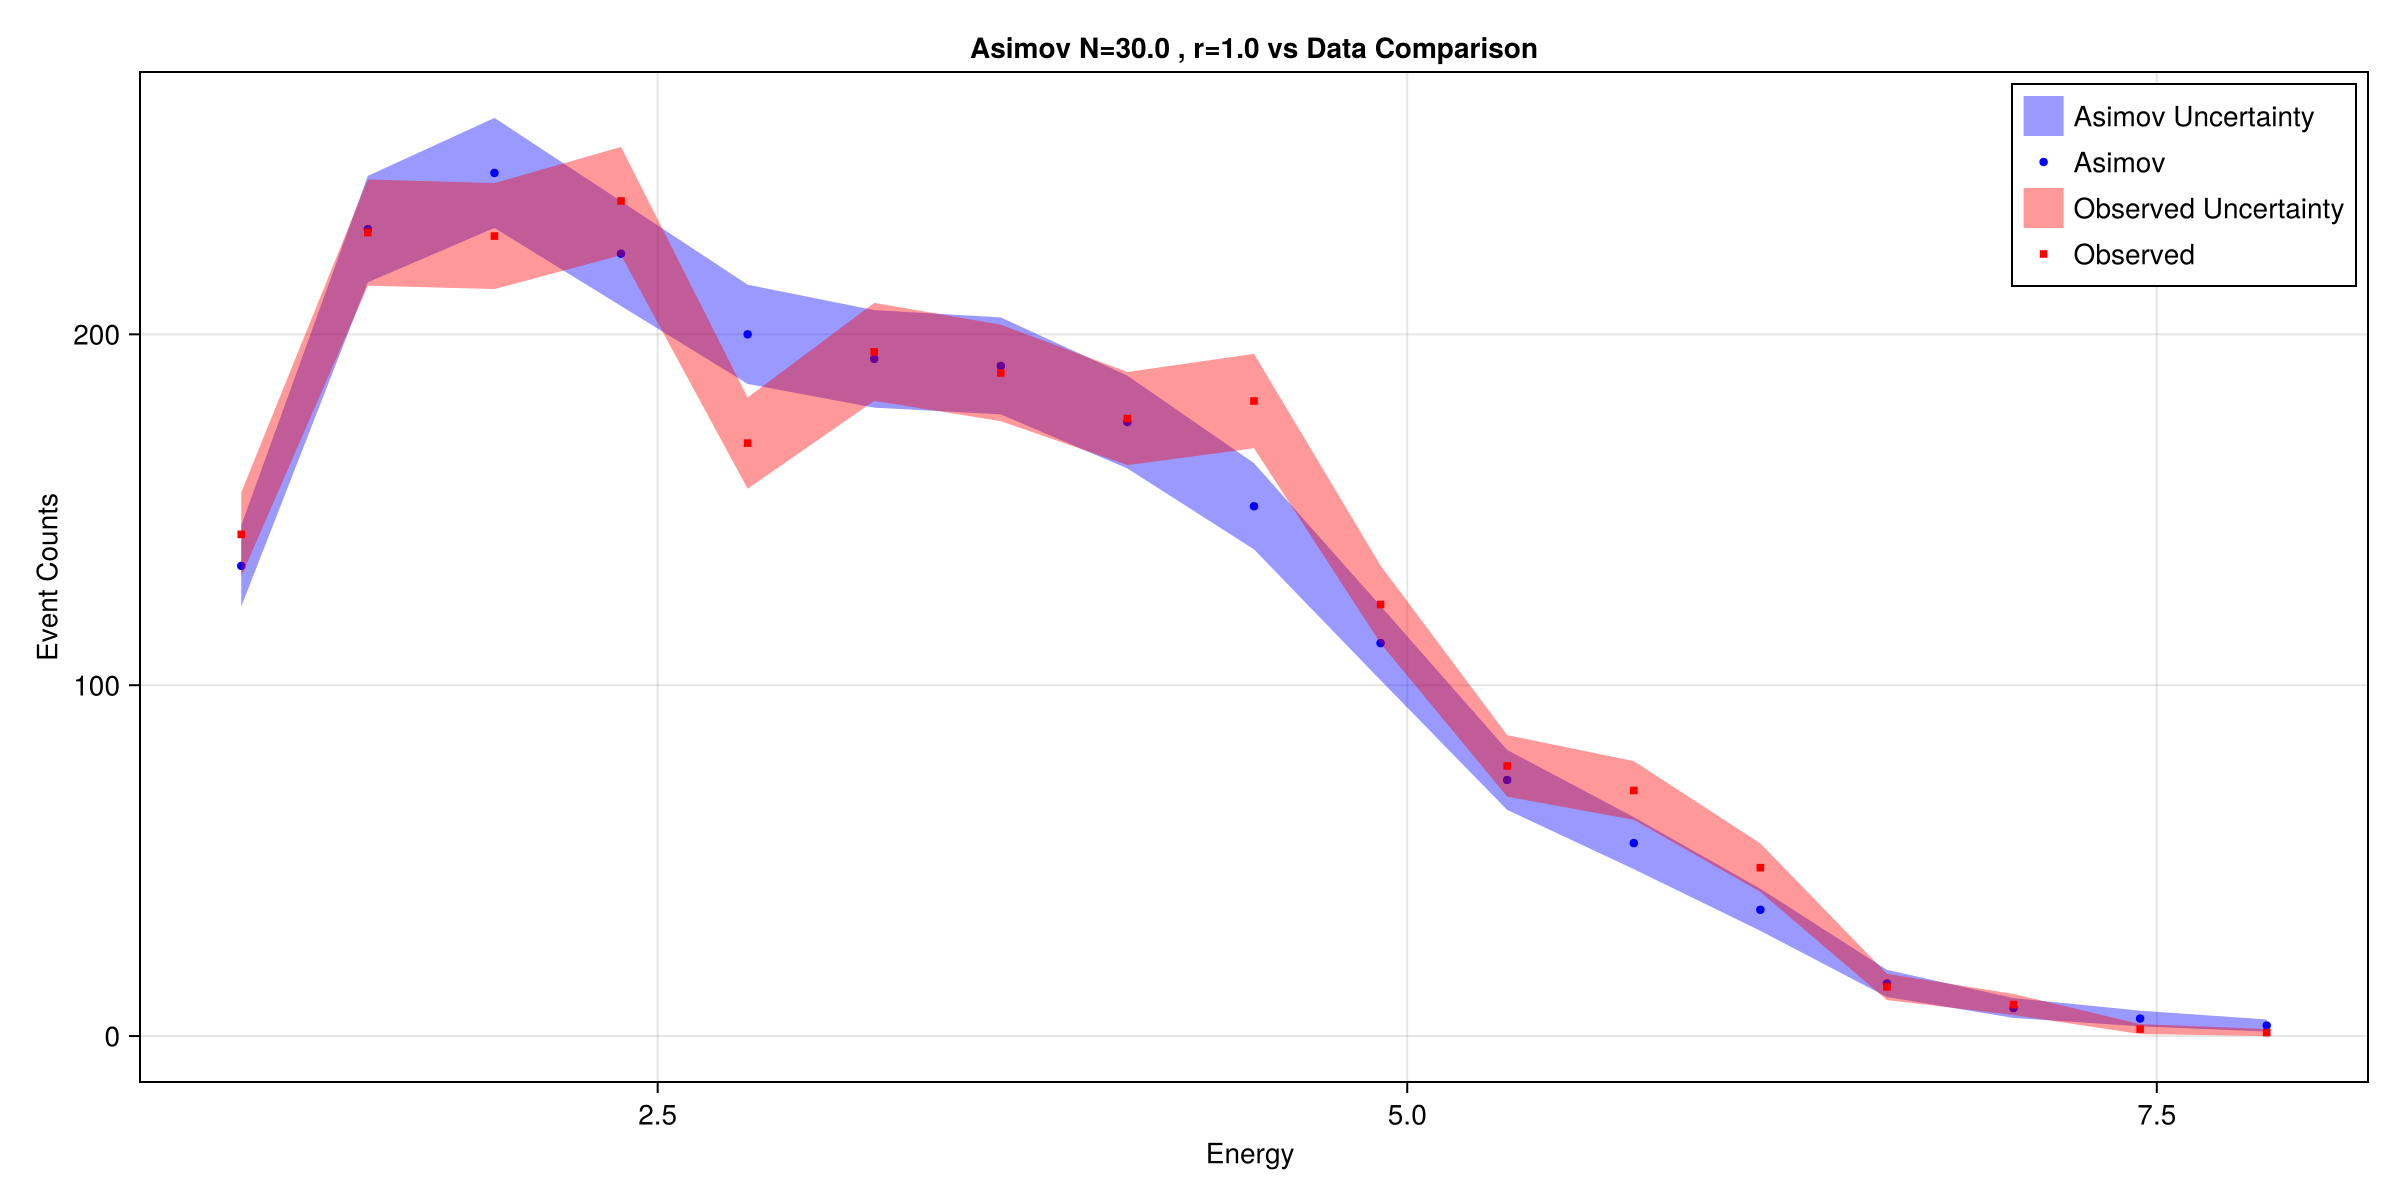

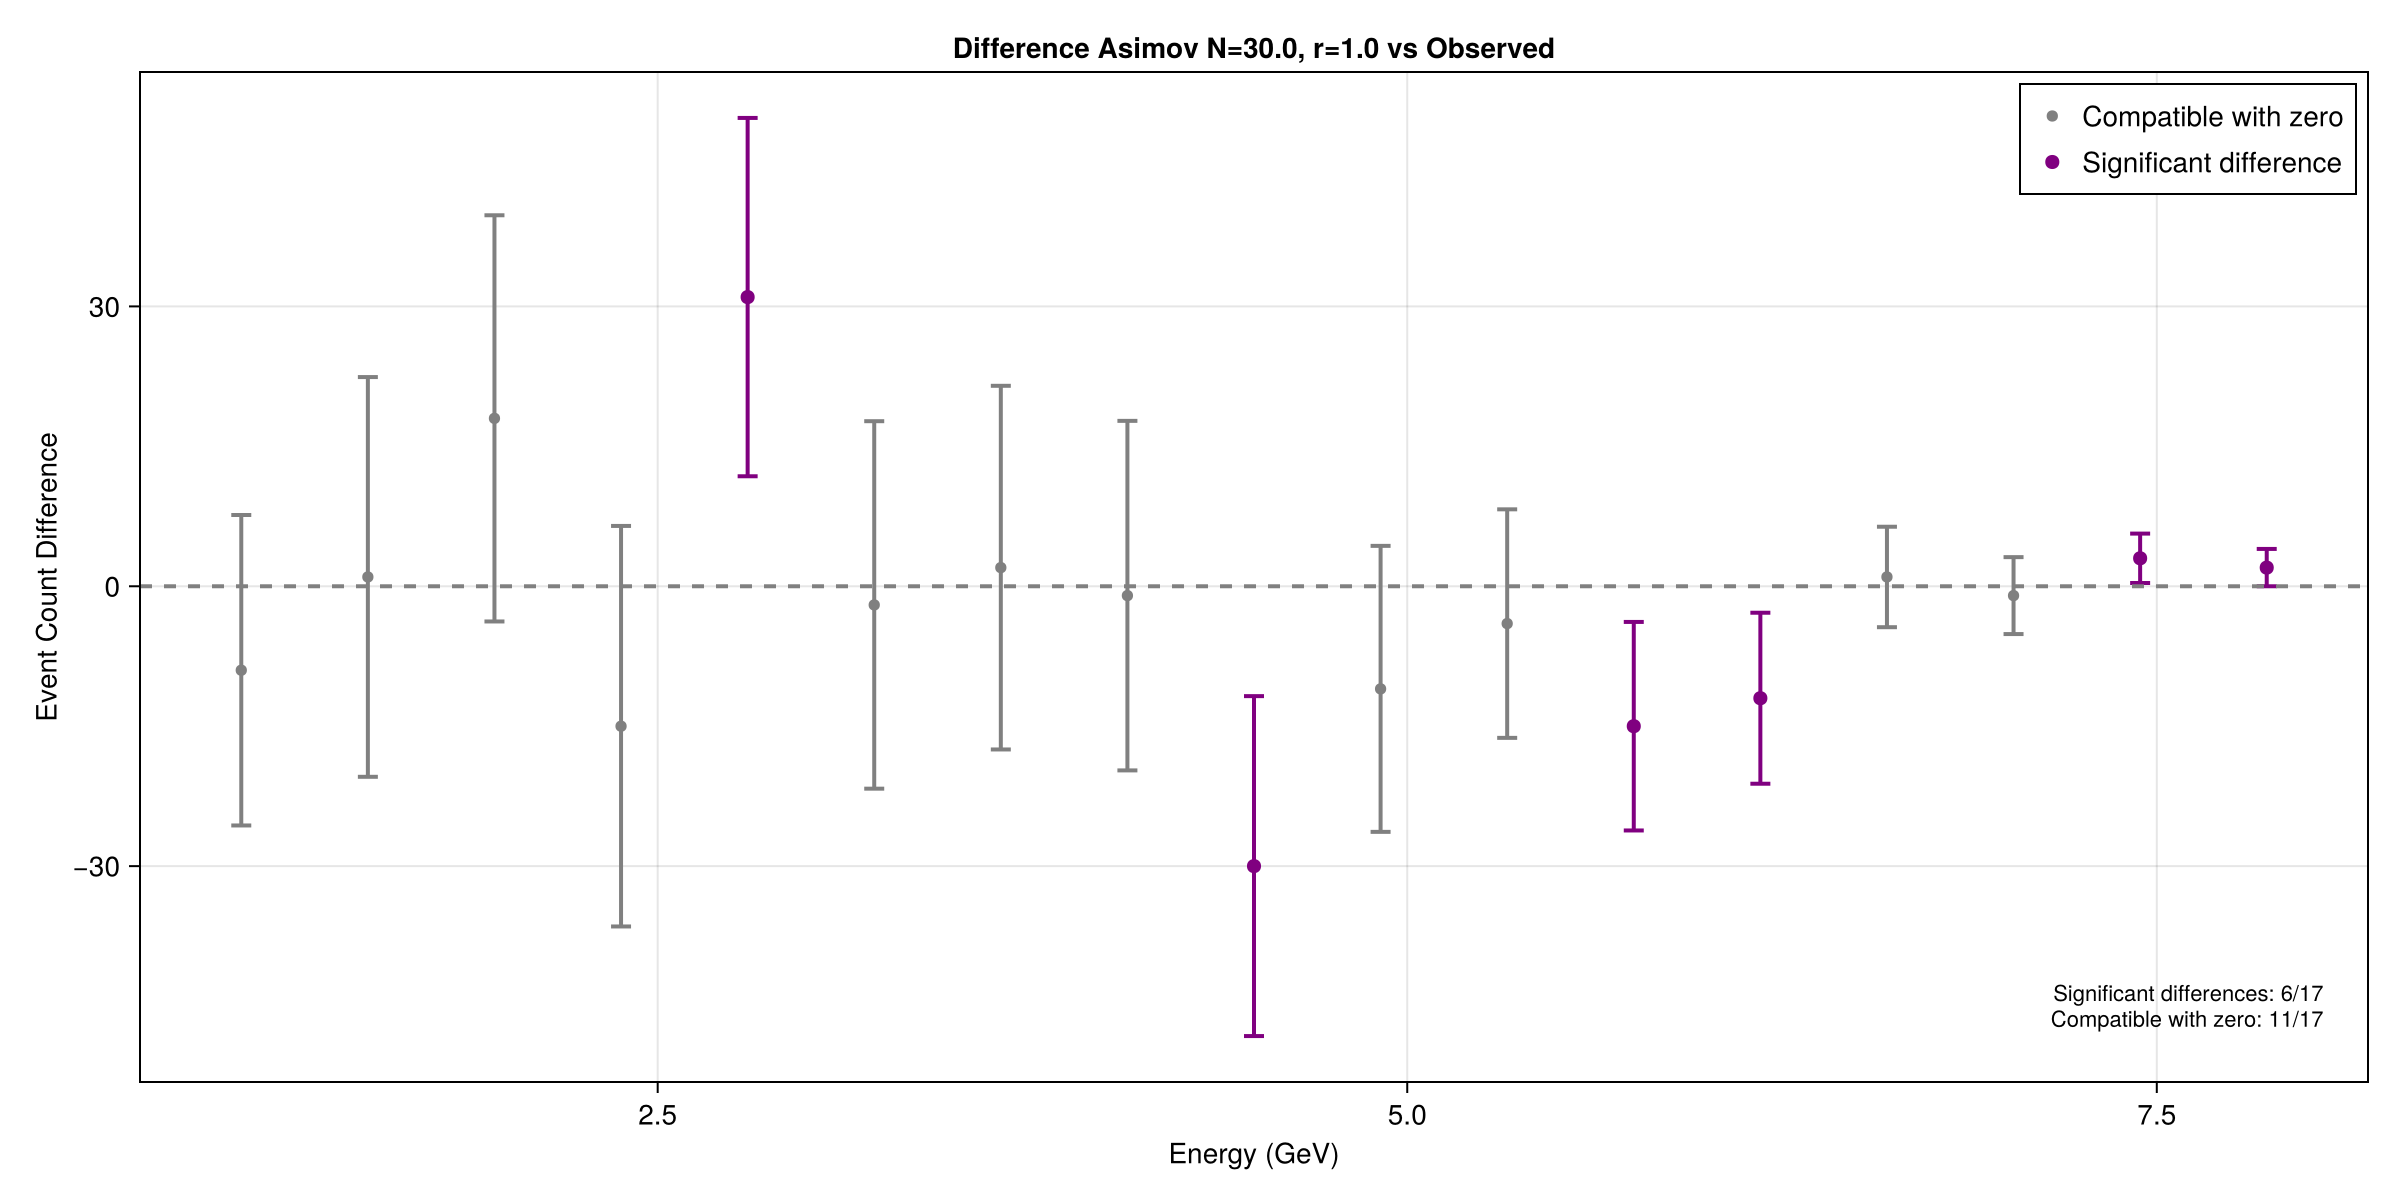

In [ ]:
N=p.N
r=p.r
# Create the figure
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
  
    xlabel = "Energy ",
    ylabel = "Event Counts", 
    title = "Asimov N=$N , r=$r vs Data Comparison")

# Plot New Model (NN) with transparent band
band!(ax, energy, asimov_data .- poisson_err_as, asimov_data .+ poisson_err_as, 
      color = (:blue, 0.4), label = "Asimov Uncertainty")
#lines!(ax, energy, toy_data_NN, 
       #color = :blue, linewidth = 2.5, label = "New Model (NN)")
scatter!(ax, energy, asimov_data, 
        color = :blue, markersize = 6, label = "Asimov")

# Plot Standard Model (SM) with transparent band
band!(ax, energy, observed_data.- poisson_err_ob, observed_data .+ poisson_err_ob, 
      color = (:red, 0.4), label = "Observed Uncertainty")
#lines!(ax, energy, toy_data_SM, 
       #color = :red, linewidth = 2.5, label = "Standard Model (SM)")
scatter!(ax, energy, observed_data, 
        color = :red, marker = :rect, markersize = 6,label = "Observed")

# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

# Show the plot
display(fig)
save("/home/sofialon/Newtrinos.jl/aug_plots/minos/minos_sensitivity_NNM_$N _$r.png", fig)

# %%
difference = asimov_data .- observed_data

# %%
error_difference= sqrt.(poisson_err_as.^2 .+ poisson_err_ob.^2)

# Create the figure
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = "Energy (GeV)",
    ylabel = "Residues ", 
    title = "Difference Asimov N=$N, r=$r vs Observed")

# Plot the difference with error bars

      
errorbars!(ax, energy, difference, error_difference, 
          color = :purple, linewidth = 2, whiskerwidth = 10, label = "Residues Uncertainty")

scatter!(ax, energy, difference, 
        color = :purple, markersize = 8)
#lines!(ax, energy, difference, 
       #color = :purple, linewidth = 1.5, alpha = 0.7)

# Add a horizontal line at zero for reference
hlines!(ax, [0], color = :gray, linestyle = :dash, linewidth = 2)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)


# Check which differences are compatible with zero (within error bars)
compatible_with_zero = abs.(difference) .<= error_difference
not_compatible_with_zero = .!compatible_with_zero

# Create the figure
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = "Energy (GeV)",
    ylabel = "Event Count Difference", 
    title =  "Difference Asimov N=$N, r=$r vs Observed")

# Plot error bars for points compatible with zero (purple/gray)
if any(compatible_with_zero)
    errorbars!(ax, energy[compatible_with_zero], difference[compatible_with_zero], 
              error_difference[compatible_with_zero],
              color = :gray, linewidth = 2, whiskerwidth = 10)
    scatter!(ax, energy[compatible_with_zero], difference[compatible_with_zero], 
            color = :gray, markersize = 8, label = "Compatible with zero")
end

# Plot error bars for points NOT compatible with zero (red)
if any(not_compatible_with_zero)
    errorbars!(ax, energy[not_compatible_with_zero], difference[not_compatible_with_zero], 
              error_difference[not_compatible_with_zero],
              color = :purple, linewidth = 2, whiskerwidth = 10)
    scatter!(ax, energy[not_compatible_with_zero], difference[not_compatible_with_zero], 
            color = :purple, markersize = 10, label = "Significant difference")
end


# Add a horizontal line at zero for reference
hlines!(ax, [0], color = :gray, linestyle = :dash, linewidth = 2)


axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

# Calculate summary statistics
n_significant = sum(not_compatible_with_zero)
n_total = length(difference)

# Get axis limits to position text box
xlims = ax.finallimits[].widths[1]
ylims = ax.finallimits[].widths[2]



summary_text = "Significant differences: $n_significant/$n_total\nCompatible with zero: $(n_total - n_significant)/$n_total"

# Re-add the text on top of the rectangle
text!(ax, 0.98, 0.05, text = summary_text,
      align = (:right, :bottom),
      space = :relative,
      fontsize = 11,
      color = :black)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)



display(fig)

save("/home/sofialon/Newtrinos.jl/aug_plots/minos/minos_sensitivity_res_NNM_$N _$r.png", fig)




Correlation r and bins counts

In [ ]:
using CairoMakie, Statistics, LinearAlgebra, Distributions
using Printf

"""
Analyze and visualize correlations between parameter r and counts per energy bin.

Parameters:
- r_values: Vector of parameter r values (between 0 and 1)
- counts_function: Function that takes r and returns counts for each energy bin
- energy_bins: Vector of energy bin centers (not edges)
- counts_matrix: Matrix of counts (rows = r values, columns = energy bins)
"""
struct ParameterCountsAnalysis
    r_values::Vector{Float64}
    counts_function::Function
    energy_bins::Vector{Float64}  # These are bin centers
    counts_matrix::Matrix{Float64}
    
    function ParameterCountsAnalysis(r_values, counts_function, energy_bins)
        # Validate inputs
        if !(0 ≤ minimum(r_values) && maximum(r_values) ≤ 1)
            @warn "r_values should be between 0 and 1"
        end
        
        # Compute counts matrix by calling function for each r value
        println("Computing counts for $(length(r_values)) r values...")
        counts_matrix = zeros(length(r_values), length(energy_bins))
        
        for (i, r) in enumerate(r_values)
            p_new = merge(p, (r=r,))    
            counts = counts_function(experiments.minos, p_new)
            if length(counts) != length(energy_bins)
                error("Function output length ($(length(counts))) must match energy_bins length ($(length(energy_bins)))")
            end
            counts_matrix[i, :] = counts
            if i % max(1, length(r_values) ÷ 10) == 0
                println("  Progress: $(i)/$(length(r_values))")
            end
        end
        println("Done computing counts matrix.")
        
        new(r_values, counts_function, energy_bins, counts_matrix)
    end
end

"""
Calculate Pearson correlation coefficient and p-value for each energy bin.
"""
function calculate_bin_correlations(analysis::ParameterCountsAnalysis)
    n_bins = size(analysis.counts_matrix, 2)
    correlations = zeros(n_bins)
    p_values = zeros(n_bins)
    
    for bin_idx in 1:n_bins
        counts_in_bin = analysis.counts_matrix[:, bin_idx]
        
        # Calculate Pearson correlation
        corr_coeff = cor(analysis.r_values, counts_in_bin)
        correlations[bin_idx] = corr_coeff
        
        # Calculate p-value (approximate for correlation test)
        n = length(analysis.r_values)
        if abs(corr_coeff) < 1.0  # Avoid division by zero
            t_stat = corr_coeff * sqrt((n - 2) / (1 - corr_coeff^2))
            # Two-tailed test
            p_values[bin_idx] = 2 * ccdf(TDist(n-2), abs(t_stat))
        else
            p_values[bin_idx] = 0.0  # Perfect correlation
        end
    end
    
    return correlations, p_values
end

"""
Calculate overall correlation using total counts across all bins.
"""
function calculate_overall_correlation(analysis::ParameterCountsAnalysis)
    total_counts = sum(analysis.counts_matrix, dims=2)[:, 1]
    overall_corr = cor(analysis.r_values, total_counts)
    
    # Calculate p-value
    n = length(analysis.r_values)
    if abs(overall_corr) < 1.0
        t_stat = overall_corr * sqrt((n - 2) / (1 - overall_corr^2))
        p_value = 2 * ccdf(TDist(n-2), abs(t_stat))
    else
        p_value = 0.0
    end
    
    return overall_corr, p_value
end

"""
Create comprehensive visualization of correlations.
"""
function plot_correlation_analysis(analysis::ParameterCountsAnalysis; 
                                 significance_level=0.05)
    
    correlations, p_values = calculate_bin_correlations(analysis)
    overall_corr, overall_p = calculate_overall_correlation(analysis)
    
    # Create figure with subplots
    fig = Figure(size=(1400, 900), fontsize=10)
    
    # 1. Correlation heatmap (top left)
    ax1 = Axis(fig[1, 1], 
              xlabel="Energy (MeV) ", 
              ylabel="Parameter r",
              title="Counts Heatmap")
    
    # Calculate bin edges correctly
    function bin_centers_to_edges(centers)
        n = length(centers)
        edges = zeros(n + 1)
        
        if n == 1
            # Single bin - use arbitrary width
            width = 0.1
            edges[1] = centers[1] - width/2
            edges[2] = centers[1] + width/2
        else
            # Multiple bins
            # First edge: extrapolate backwards
            edges[1] = centers[1] - (centers[2] - centers[1])/2
            
            # Middle edges: midpoints between consecutive centers
            for i in 2:n
                edges[i] = (centers[i-1] + centers[i])/2
            end
            
            # Last edge: extrapolate forwards
            edges[n+1] = centers[n] + (centers[n] - centers[n-1])/2
        end
        
        return edges
    end
    
    # Calculate edges
    energy_edges = bin_centers_to_edges(analysis.energy_bins)
    r_edges = bin_centers_to_edges(analysis.r_values)
    
    transposed_matrix = transpose(analysis.counts_matrix)
    
    hm = heatmap!(ax1, energy_edges, r_edges, transposed_matrix, colormap=:viridis)
    Colorbar(fig[1, 1, Right()], hm)
    
    # 2. Correlation by bin (top right)
    ax2 = Axis(fig[1, 2],
              xlabel="Energy (MeV)",
              ylabel="Correlation Coefficient",
              title="Correlation by Energy Bin")
    
    # Color points by significance
    significant = p_values .< significance_level
    scatter!(ax2, analysis.energy_bins[significant], correlations[significant],
            color=:red, markersize=8, label="Significant (p < $significance_level)")
    scatter!(ax2, analysis.energy_bins[.!significant], correlations[.!significant],
            color=:blue, markersize=8, label="Not significant")
    
    # Add horizontal line at zero
    hlines!(ax2, [0], color=:black, linestyle=:dash, alpha=0.5)
    
    # Add significance threshold lines (approximate)
    n = length(analysis.r_values)
    critical_r = sqrt(4 / (n - 2))  # Approximate critical value for p=0.05
    hlines!(ax2, [critical_r, -critical_r], color=:red, alpha=0.3)
    
    axislegend(ax2, position=:rt)
    
    # 3. Example scatter plot (bottom left)
    ax3 = Axis(fig[2, 1],
              xlabel="Parameter r",
              ylabel="Counts")
    
    # Find bin with strongest correlation
    max_corr_idx = argmax(abs.(correlations))
    counts_example = analysis.counts_matrix[:, max_corr_idx]
    corr_val = correlations[max_corr_idx]
    
    scatter!(ax3, analysis.r_values, counts_example, 
            color=:blue, alpha=0.7, markersize=6)
    
    # Add trend line
    X = hcat(ones(length(analysis.r_values)), analysis.r_values)
    β = X \ counts_example
    r_range = range(minimum(analysis.r_values), maximum(analysis.r_values), length=100)
    trend = β[1] .+ β[2] .* r_range
    lines!(ax3, r_range, trend, color=:red, linewidth=2)
    
    ax3.title = @sprintf("Example: Bin %.2f (r = %.3f)", 
                        analysis.energy_bins[max_corr_idx], corr_val)
    
    # 4. Overall correlation (bottom right)
    ax4 = Axis(fig[2, 2],
              xlabel="Parameter r",
              ylabel="Total Counts")
    
    total_counts = sum(analysis.counts_matrix, dims=2)[:, 1]
    scatter!(ax4, analysis.r_values, total_counts,
            color=:green, alpha=0.7, markersize=6)
    
    # Add trend line for overall correlation
    X = hcat(ones(length(analysis.r_values)), analysis.r_values)
    β = X \ total_counts
    r_range = range(minimum(analysis.r_values), maximum(analysis.r_values), length=100)
    trend = β[1] .+ β[2] .* r_range
    lines!(ax4, r_range, trend, color=:red, linewidth=2)
    
    ax4.title = @sprintf("Overall Correlation\nr = %.3f, p = %.4f", 
                        overall_corr, overall_p)
    
    # Add main title
    fig[0, :] = Label(fig, " minos- r vs counts correlation, N=$N ", 
                     fontsize=16, font="bold")
    
    return fig, correlations, p_values, overall_corr, overall_p
end

"""
Print comprehensive summary statistics.
"""
function print_summary(analysis::ParameterCountsAnalysis, 
                      correlations, p_values, overall_corr, overall_p;
                      significance_level=0.05)
    
    println("=== Correlation Analysis Summary ===")
    println()
    
    # Data overview
    println("Data Overview:")
    println("  Number of r values: $(length(analysis.r_values))")
    println("  r range: [$(minimum(analysis.r_values)), $(maximum(analysis.r_values))]")
    println("  Number of energy bins: $(length(analysis.energy_bins))")
    println("  Energy range: [$(minimum(analysis.energy_bins)), $(maximum(analysis.energy_bins))]")
    println()
    
    # Overall correlation
    println("Overall Correlation (Total Counts vs r):")
    println("  Correlation coefficient: $(@sprintf("%.4f", overall_corr))")
    println("  p-value: $(@sprintf("%.6f", overall_p))")
    println("  Significant: $(overall_p < significance_level ? "Yes" : "No")")
    println()
    
    # Bin-wise statistics
    significant_bins = sum(p_values .< significance_level)
    positive_corr = sum(correlations .> 0)
    negative_corr = sum(correlations .< 0)
    
    println("Bin-wise Correlations:")
    println("  Significant correlations (p < $significance_level): $significant_bins/$(length(correlations))")
    println("  Positive correlations: $positive_corr")
    println("  Negative correlations: $negative_corr")
    println("  Max correlation: $(@sprintf("%.4f", maximum(correlations))) (bin $(@sprintf("%.2f", analysis.energy_bins[argmax(correlations)])))")
    println("  Min correlation: $(@sprintf("%.4f", minimum(correlations))) (bin $(@sprintf("%.2f", analysis.energy_bins[argmin(correlations)])))")
    println("  Mean correlation: $(@sprintf("%.4f", mean(correlations)))")
    println("  Std correlation: $(@sprintf("%.4f", std(correlations)))")
    println()
    
    # Most significant correlations
    sorted_indices = sortperm(p_values)
    println("Top 5 most significant correlations:")
    for i in 1:min(5, length(sorted_indices))
        idx = sorted_indices[i]
        println("  Bin $(@sprintf("%.2f", analysis.energy_bins[idx])): r = $(@sprintf("%.4f", correlations[idx])), p = $(@sprintf("%.6f", p_values[idx]))")
    end
    
    # Strongest correlations (by absolute value)
    strongest_indices = sortperm(abs.(correlations), rev=true)
    println()
    println("Top 5 strongest correlations (by absolute value):")
    for i in 1:min(5, length(strongest_indices))
        idx = strongest_indices[i]
        println("  Bin $(@sprintf("%.2f", analysis.energy_bins[idx])): r = $(@sprintf("%.4f", correlations[idx])), p = $(@sprintf("%.6f", p_values[idx]))")
    end
end

"""
Save results to files.
"""
function save_results(analysis::ParameterCountsAnalysis, 
                     correlations, p_values, overall_corr, overall_p;
                     filename_prefix="correlation_analysis")
    
    # Save correlation results
    results_df = DataFrame(
        energy_bin = analysis.energy_bins,
        correlation = correlations,
        p_value = p_values,
        significant = p_values .< 0.05
    )
    
    # Save to CSV (you'll need to add CSV package: using CSV)
    # CSV.write("$(filename_prefix)_results.csv", results_df)
    
    # Save counts matrix
    counts_df = DataFrame(analysis.counts_matrix, :auto)
    insertcols!(counts_df, 1, :r_values => analysis.r_values)
    
    # CSV.write("$(filename_prefix)_counts.csv", counts_df)
    
    println("Results saved to $(filename_prefix)_results.csv and $(filename_prefix)_counts.csv")
    println("(Uncomment CSV.write lines and add 'using CSV' to enable file saving)")
    
    return results_df, counts_df
end



save_results

[ Info: Poisson-based model. Rounding Asimov data to nearest integer.


Computing counts for 50 r values...


[ Info: Poisson-based model. Rounding Asimov data to nearest integer.
[ Info: Poisson-based model. Rounding Asimov data to nearest integer.
[ Info: Poisson-based model. Rounding Asimov data to nearest integer.
[ Info: Poisson-based model. Rounding Asimov data to nearest integer.
[ Info: Poisson-based model. Rounding Asimov data to nearest integer.


  Progress: 5/50


[ Info: Poisson-based model. Rounding Asimov data to nearest integer.
[ Info: Poisson-based model. Rounding Asimov data to nearest integer.
[ Info: Poisson-based model. Rounding Asimov data to nearest integer.
[ Info: Poisson-based model. Rounding Asimov data to nearest integer.
[ Info: Poisson-based model. Rounding Asimov data to nearest integer.


...

[ Info: Poisson-based model. Rounding Asimov data to nearest integer.
[ Info: Poisson-based model. Rounding Asimov data to nearest integer.
[ Info: Poisson-based model. Rounding Asimov data to nearest integer.
[ Info: Poisson-based model. Rounding Asimov data to nearest integer.
[ Info: Poisson-based model. Rounding Asimov data to nearest integer.


  Progress: 45/50


[ Info: Poisson-based model. Rounding Asimov data to nearest integer.
[ Info: Poisson-based model. Rounding Asimov data to nearest integer.
[ Info: Poisson-based model. Rounding Asimov data to nearest integer.
[ Info: Poisson-based model. Rounding Asimov data to nearest integer.
[ Info: Poisson-based model. Rounding Asimov data to nearest integer.


  Progress: 50/50
Done computing counts matrix.


┌ Warning: Could not find font bold, using TeX Gyre Heros Makie
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/conversions.jl:1421


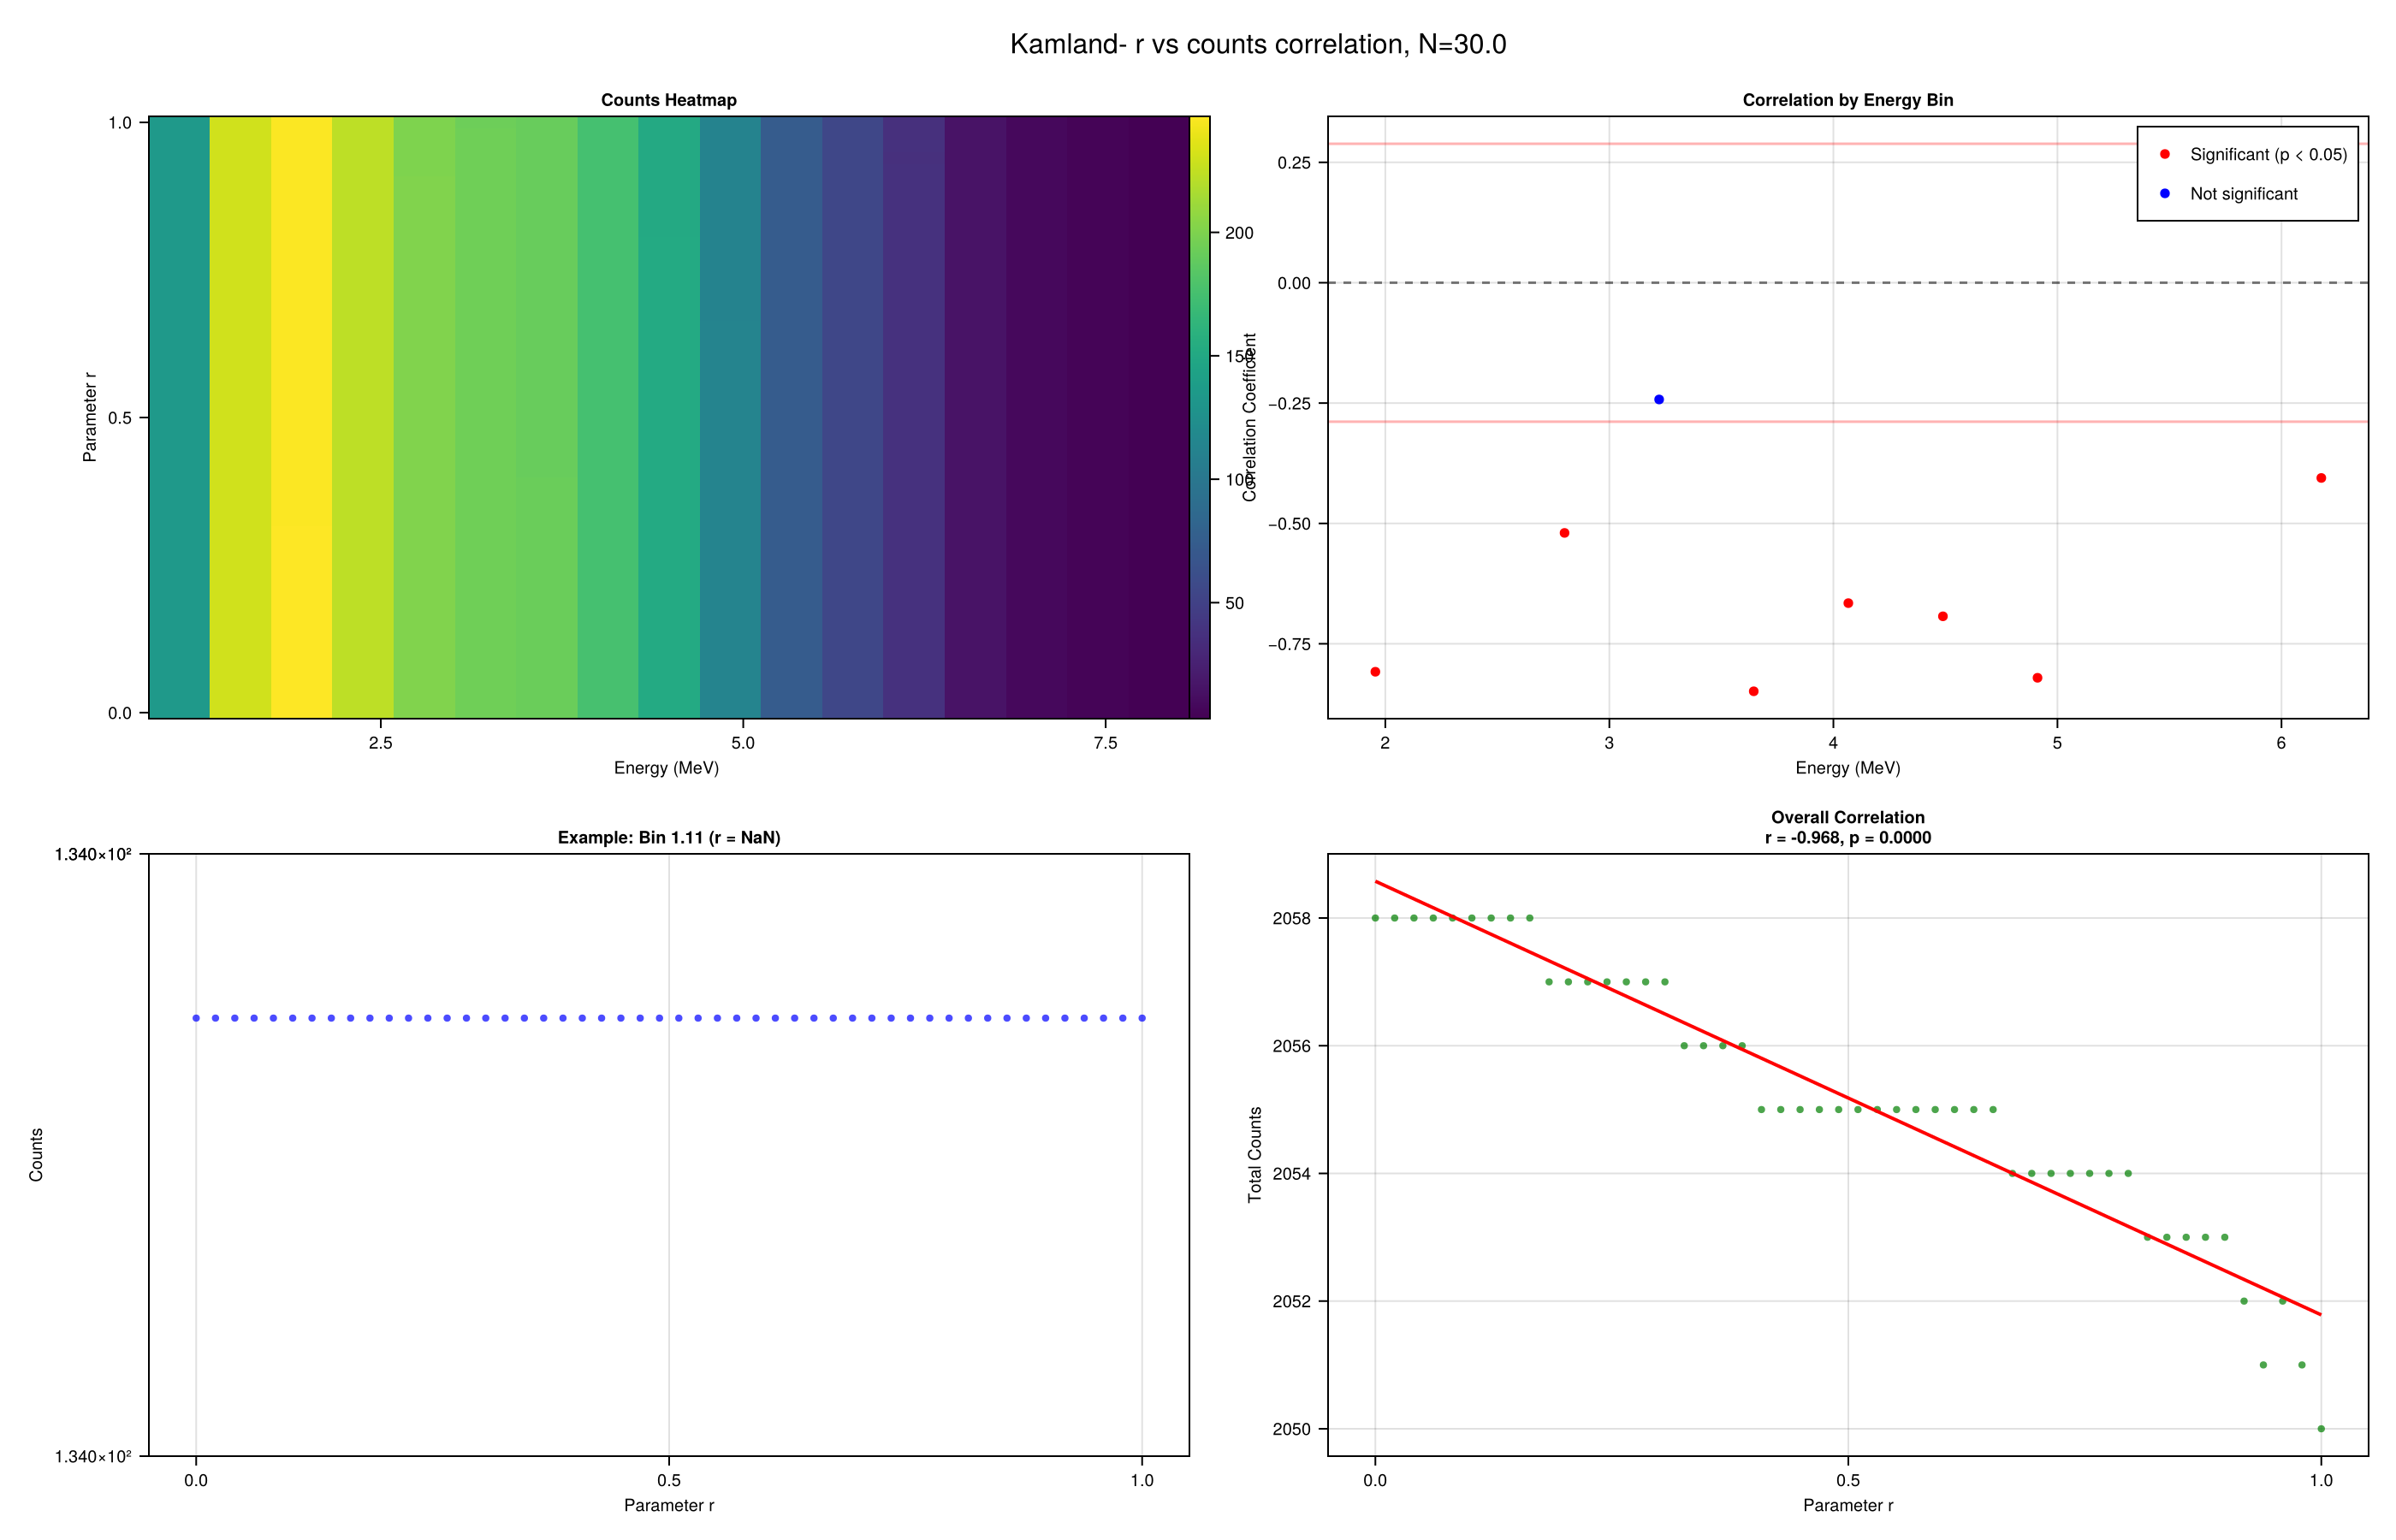

=== Correlation Analysis Summary ===

Data Overview:
  Number of r values: 50
  r range: [0.0, 1.0]
  Number of energy bins: 17
  Energy range: [1.1111111111111112, 7.866666666666666]

Overall Correlation (Total Counts vs r):
  Correlation coefficient: -0.9684
  p-value: 0.000000
  Significant: Yes

Bin-wise Correlations:
  Significant correlations (p < 0.05): 16/17
  Positive correlations: 0
  Negative correlations: 8
  Max correlation: NaN (bin 1.11)
  Min correlation: NaN (bin 1.11)
  Mean correlation: NaN
  Std correlation: NaN

Top 5 most significant correlations:
  Bin 1.11: r = NaN, p = 0.000000
  Bin 1.53: r = NaN, p = 0.000000
  Bin 2.38: r = NaN, p = 0.000000
  Bin 5.33: r = NaN, p = 0.000000
  Bin 5.76: r = NaN, p = 0.000000

Top 5 strongest correlations (by absolute value):
  Bin 1.11: r = NaN, p = 0.000000
  Bin 1.53: r = NaN, p = 0.000000
  Bin 2.38: r = NaN, p = 0.000000
  Bin 5.33: r = NaN, p = 0.000000
  Bin 5.76: r = NaN, p = 0.000000


In [ ]:
counts=Newtrinos.generate_asimov_data(experiments.minos, p)
fun=Newtrinos.generate_asimov_data
# Define your setup
r_values = collect(range(0, 1, length=50))  # Your r parameter values
energy_bins = energy #experiments.dayabay.assets.energy_bins

# Create analysis object (this will call your function for each r)
analysis = ParameterCountsAnalysis(r_values, fun, energy_bins)

# Run analysis and create plots
fig, correlations, p_values, overall_corr, overall_p = plot_correlation_analysis(analysis)

# Display or save the plot
display(fig)
save("/home/sofialon/Newtrinos.jl/aug_plots/minos/correlation_analysis_NNM_N=$N.png", fig)

# Print detailed summary
print_summary(analysis, correlations, p_values, overall_corr, overall_p)
